In [ ]:
import pandas as pd
df = pd.read_csv('/content/bank_transactions.csv')

In [ ]:
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,"17,819.05",2/8/16,143207,25.00
1,T2,C2142763,4/4/57,M,JHAJJAR,"2,270.69",2/8/16,141858,"27,999.00"
2,T3,C4417068,26/11/96,F,MUMBAI,"17,874.44",2/8/16,142712,459.00
3,T4,C5342380,14/9/73,F,MUMBAI,"866,503.21",2/8/16,142714,"2,060.00"
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,"6,714.43",2/8/16,181156,"1,762.50"


In [ ]:
df.tail()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
1048562,T1048563,C8020229,8/4/90,M,NEW DELHI,"7,635.19",18/9/16,184824,799.00
1048563,T1048564,C6459278,20/2/92,M,NASHIK,"27,311.42",18/9/16,183734,460.00
1048564,T1048565,C6412354,18/5/89,M,HYDERABAD,"221,757.06",18/9/16,183313,770.00
1048565,T1048566,C6420483,30/8/78,M,VISAKHAPATNAM,"10,117.87",18/9/16,184706,"1,000.00"
1048566,T1048567,C8337524,5/3/84,M,PUNE,"75,734.42",18/9/16,181222,"1,166.00"


In [ ]:
df.columns

Index(['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender',
       'CustLocation', 'CustAccountBalance', 'TransactionDate',
       'TransactionTime', 'TransactionAmount (INR)'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,3397
CustGender,1100
CustLocation,151
CustAccountBalance,2369
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0


In [ ]:
df.isna().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,3397
CustGender,1100
CustLocation,151
CustAccountBalance,2369
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0


In [ ]:
df.dtypes

,0
TransactionID,object
CustomerID,object
CustomerDOB,object
CustGender,object
CustLocation,object
CustAccountBalance,float64
TransactionDate,object
TransactionTime,int64
TransactionAmount (INR),float64


In [ ]:
df = df[df['CustomerDOB'] != '1/1/1800']

In [ ]:
df.head(20)

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,"17,819.05",2/8/16,143207,25.00
1,T2,C2142763,4/4/57,M,JHAJJAR,"2,270.69",2/8/16,141858,"27,999.00"
2,T3,C4417068,26/11/96,F,MUMBAI,"17,874.44",2/8/16,142712,459.00
3,T4,C5342380,14/9/73,F,MUMBAI,"866,503.21",2/8/16,142714,"2,060.00"
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,"6,714.43",2/8/16,181156,"1,762.50"
5,T6,C1536588,8/10/72,F,ITANAGAR,"53,609.20",2/8/16,173940,676.00
6,T7,C7126560,26/1/92,F,MUMBAI,973.46,2/8/16,173806,566.00
7,T8,C1220223,27/1/82,M,MUMBAI,"95,075.54",2/8/16,170537,148.00
8,T9,C8536061,19/4/88,F,GURGAON,"14,906.96",2/8/16,192825,833.00
9,T10,C6638934,22/6/84,M,MUMBAI,"4,279.22",2/8/16,192446,289.11


In [ ]:
def convert_dob(x):
    if pd.isna(x):
        return pd.NaT

    if isinstance(x, pd.Timestamp):
        return x

    day, month, year = map(int, str(x).split("/"))

    if year > 16:
        year += 1900
    else:
        year += 2000

    return pd.Timestamp(year=year, month=month, day=day)

In [ ]:
df["CustomerDOB"] = df["CustomerDOB"].apply(convert_dob)

In [ ]:
df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"],
    dayfirst=True,
    errors="coerce"
)

/tmp/ipykernel_929/3113511040.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TransactionDate"] = pd.to_datetime(


In [ ]:
df["Age"] = (
    (df["TransactionDate"] - df["CustomerDOB"]).dt.days / 365.25
).round()

In [ ]:
df["Age"] = df["Age"].astype("Int64")

In [ ]:
df[['Age', 'CustomerDOB', 'TransactionDate']].head()

,Age,CustomerDOB,TransactionDate
0,23,1994-01-10,2016-08-02
1,59,1957-04-04,2016-08-02
2,20,1996-11-26,2016-08-02
3,43,1973-09-14,2016-08-02
4,28,1988-03-24,2016-08-02


In [ ]:
df['Age'].describe()

,Age
count,"987,831.00"
mean,31.18
std,8.77
min,0.00
25%,25.00
50%,29.00
75%,35.00
max,98.00


In [ ]:
df[df["Age"] == 0]

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
114611,T114612,C2846955,2016-02-22,M,SURAT,"16,205.90",2016-08-06,184630,460.00,0
128470,T128471,C6946973,2016-02-22,M,SURAT,"16,205.90",2016-08-06,180116,294.00,0


In [ ]:
df[df["Age"] == 98]

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),Age
914000,T914001,C2638825,1918-05-03,F,MUMBAI,"11,725.34",2016-09-12,183842,250.00,98


In [ ]:
df = df.drop(['CustomerDOB', 'TransactionDate'], axis=1)

In [ ]:
num_cols = df.select_dtypes(include='number').columns
outlier_columns = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    outlier_columns.append(col)
    print(f"{col}: {len(outliers)} outliers")

CustAccountBalance: 131131 outliers
TransactionTime: 17696 outliers
TransactionAmount (INR): 105522 outliers
Age: 40536 outliers


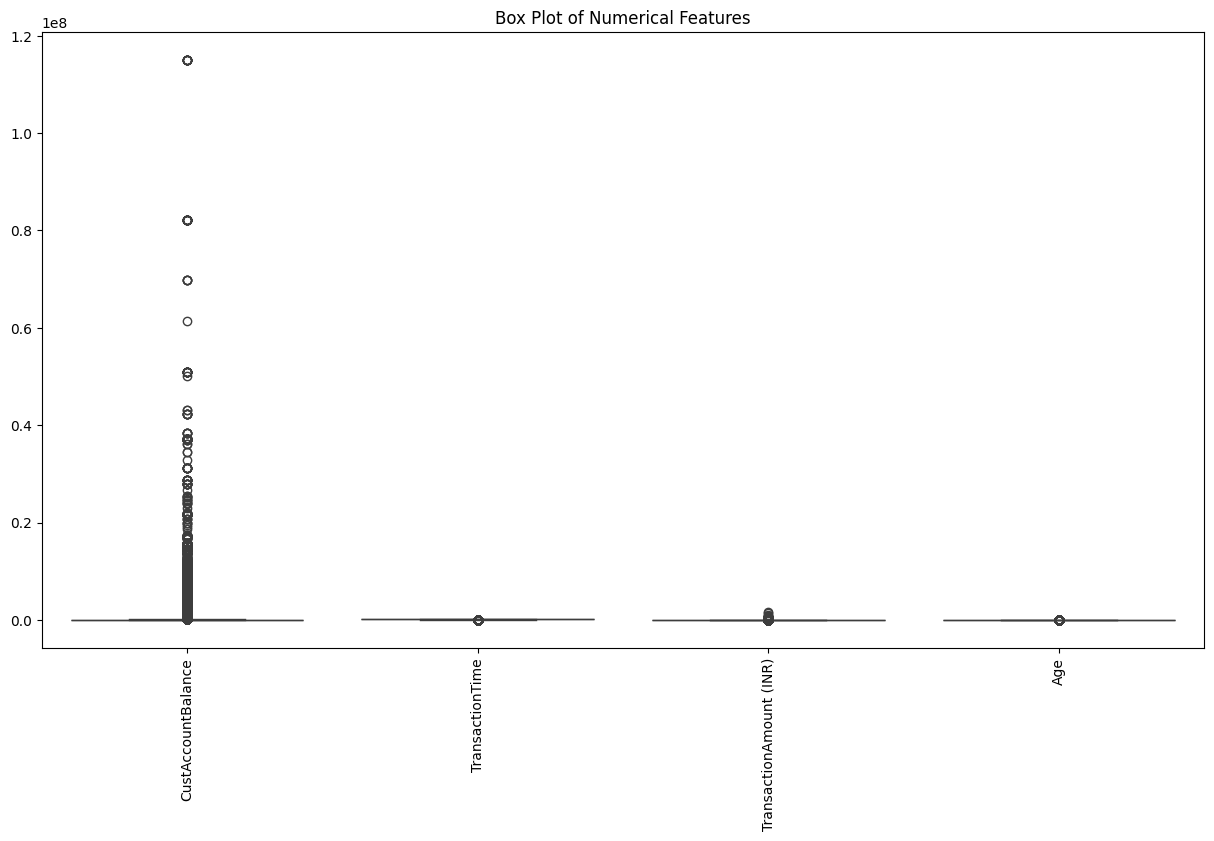

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[outlier_columns])

plt.xticks(rotation=90)
plt.title("Box Plot of Numerical Features")
plt.show()

In [ ]:
df = df[(df["Age"] >= lower) &
        (df["Age"] <= upper)]

In [ ]:
df.columns

Index(['TransactionID', 'CustomerID', 'CustGender', 'CustLocation',
       'CustAccountBalance', 'TransactionTime', 'TransactionAmount (INR)',
       'Age'],
      dtype='object')

In [ ]:
dx = df[['CustGender', 'CustLocation',
       'CustAccountBalance', 'TransactionAmount (INR)',
       'Age']].copy()

In [ ]:
dx.head()

,CustGender,CustLocation,CustAccountBalance,TransactionAmount (INR),Age
0,F,JAMSHEDPUR,"17,819.05",25.00,23
2,F,MUMBAI,"17,874.44",459.00,20
3,F,MUMBAI,"866,503.21","2,060.00",43
4,F,NAVI MUMBAI,"6,714.43","1,762.50",28
5,F,ITANAGAR,"53,609.20",676.00,44


In [ ]:
dx.columns

Index(['CustGender', 'CustLocation', 'CustAccountBalance',
       'TransactionAmount (INR)', 'Age'],
      dtype='object')

In [ ]:
df_temp = dx[['CustGender', 'CustLocation', 'CustAccountBalance',
       'TransactionAmount (INR)', 'Age']].copy()

In [ ]:
inactive_users = dx[(dx['CustAccountBalance'] == 0) | (dx['TransactionAmount (INR)'] == 0)]
active_users = dx[(dx['CustAccountBalance'] > 0) & (dx['TransactionAmount (INR)'] > 0)].copy()

In [ ]:
dx = active_users.copy()

In [ ]:
df_temp.head()

,CustGender,CustLocation,CustAccountBalance,TransactionAmount (INR),Age
0,F,JAMSHEDPUR,"17,819.05",25.00,23
2,F,MUMBAI,"17,874.44",459.00,20
3,F,MUMBAI,"866,503.21","2,060.00",43
4,F,NAVI MUMBAI,"6,714.43","1,762.50",28
5,F,ITANAGAR,"53,609.20",676.00,44


In [ ]:
columns_to_cap = [
    'CustAccountBalance',
    'TransactionAmount (INR)',
    'Age'
]

for col in columns_to_cap:
    if dx[col].dtype == 'Int64':
        dx[col] = dx[col].astype(float)

    Q1 = dx[col].quantile(0.25)
    Q3 = dx[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    dx[col] = dx[col].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
import numpy as np

financial_cols = ['CustAccountBalance', 'TransactionAmount (INR)']

for col in financial_cols:
    dx[col] = np.log1p(dx[col])

In [ ]:
dx.head()

,CustGender,CustLocation,CustAccountBalance,TransactionAmount (INR),Age
0,F,JAMSHEDPUR,9.79,3.26,23.00
2,F,MUMBAI,9.79,6.13,20.00
3,F,MUMBAI,11.70,7.63,43.00
4,F,NAVI MUMBAI,8.81,7.48,28.00
5,F,ITANAGAR,10.89,6.52,44.00


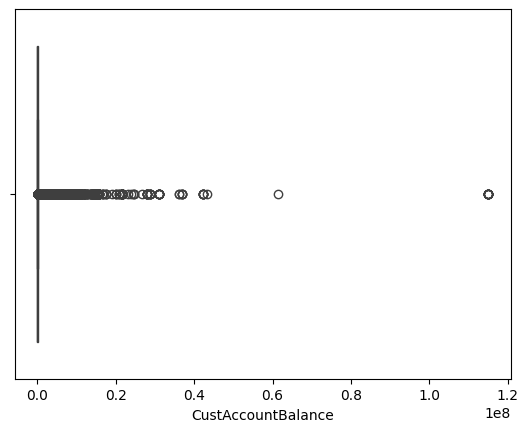

In [ ]:
sns.boxplot(x=df["CustAccountBalance"])
plt.show()

In [ ]:
dx.isnull().sum()

,0
CustGender,13
CustLocation,151
CustAccountBalance,0
TransactionAmount (INR),0
Age,0


In [ ]:
dx = dx.dropna()

In [ ]:
dx.isnull().sum()

,0
CustGender,0
CustLocation,0
CustAccountBalance,0
TransactionAmount (INR),0
Age,0


In [ ]:
dx.duplicated().sum()

np.int64(217680)

In [ ]:
dx.duplicated().any()

np.True_

In [ ]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [ ]:
dx.columns

Index(['CustGender', 'CustLocation', 'CustAccountBalance',
       'TransactionAmount (INR)', 'Age'],
      dtype='object')

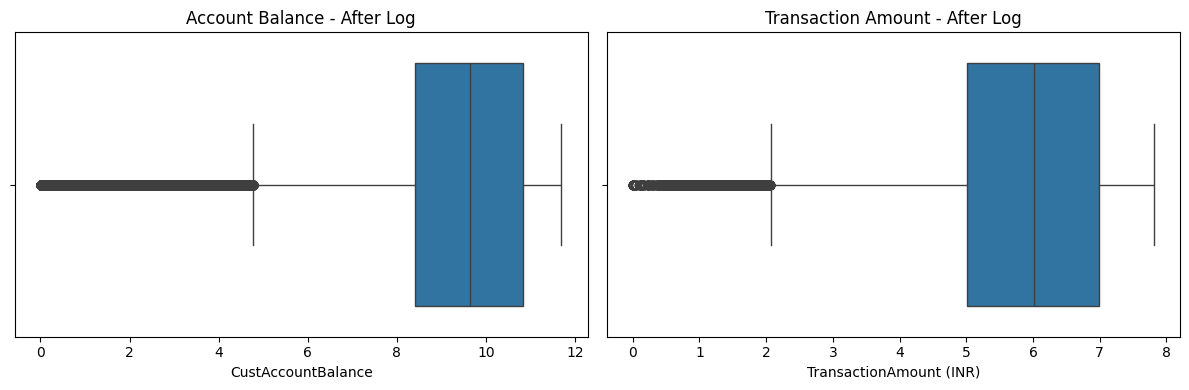

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=dx["CustAccountBalance"], ax=axes[0])
axes[0].set_title("Account Balance - After Log")

sns.boxplot(x=dx["TransactionAmount (INR)"], ax=axes[1])
axes[1].set_title("Transaction Amount - After Log")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(dx["CustGender"])
dx["CustGender"] = le.transform(dx["CustGender"])

In [ ]:
dx.head()

,CustGender,CustLocation,CustAccountBalance,TransactionAmount (INR),Age
0,0,JAMSHEDPUR,9.79,3.26,23.00
2,0,MUMBAI,9.79,6.13,20.00
3,0,MUMBAI,11.70,7.63,43.00
4,0,NAVI MUMBAI,8.81,7.48,28.00
5,0,ITANAGAR,10.89,6.52,44.00


In [ ]:
df['CustLocation'].nunique()

7916

In [ ]:
location_freq = dx["CustLocation"].value_counts()

dx["CustLocation"] = (
    dx["CustLocation"].map(location_freq)
)

In [ ]:
dx.head()

,CustGender,CustLocation,CustAccountBalance,TransactionAmount (INR),Age
0,0,1468,9.79,3.26,23.00
2,0,93620,9.79,6.13,20.00
3,0,93620,11.70,7.63,43.00
4,0,11371,8.81,7.48,28.00
5,0,200,10.89,6.52,44.00


In [ ]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
le = LabelEncoder()
dx["CustGender"] = le.fit_transform(dx["CustGender"])
location_freq = dx["CustLocation"].value_counts()
dx["CustLocation"] = dx["CustLocation"].map(location_freq)

scaler = MinMaxScaler()
dx_scaled = scaler.fit_transform(dx)

In [ ]:
dx_scaled = pd.DataFrame(dx_scaled, columns=dx.columns)
dx_scaled.head()

,CustGender,CustLocation,CustAccountBalance,TransactionAmount (INR),Age
0,0.00,0.01,0.84,0.42,0.32
1,0.00,1.00,0.84,0.78,0.24
2,0.00,1.00,1.00,0.98,0.88
3,0.00,0.12,0.75,0.96,0.46
4,0.00,0.00,0.93,0.83,0.90


In [ ]:
from sklearn.cluster import KMeans
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(dx_scaled)
    inertia.append(kmeans.inertia_)

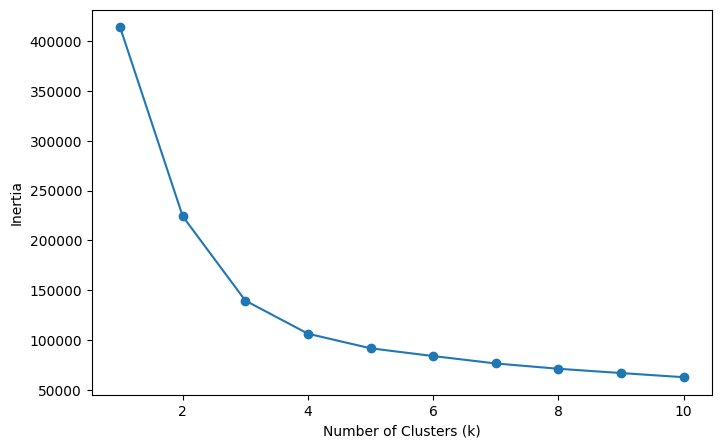

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

sample = dx_scaled.sample(
    n=10000,
    random_state=42
)

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(sample)

    score = silhouette_score(sample, labels)

    print(f"k={k}: {score:.3f}")

k=2: 0.479
k=3: 0.469
k=4: 0.485
k=5: 0.380
k=6: 0.328
k=7: 0.327
k=8: 0.325
k=9: 0.321
k=10: 0.283


In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(dx_scaled)

dx["Cluster"] = labels

In [ ]:
dx["Cluster"].value_counts().sort_index()

,count
Cluster,
0,428487
1,118648
2,253616
3,141883


In [ ]:
dx.columns

Index(['CustGender', 'CustLocation', 'CustAccountBalance',
       'TransactionAmount (INR)', 'Age', 'Cluster'],
      dtype='object')

In [ ]:
df_temp.head()

,CustGender,CustLocation,CustAccountBalance,TransactionAmount (INR),Age
0,F,JAMSHEDPUR,"17,819.05",25.00,23
2,F,MUMBAI,"17,874.44",459.00,20
3,F,MUMBAI,"866,503.21","2,060.00",43
4,F,NAVI MUMBAI,"6,714.43","1,762.50",28
5,F,ITANAGAR,"53,609.20",676.00,44


In [ ]:
df_temp.columns

Index(['CustGender', 'CustLocation', 'CustAccountBalance',
       'TransactionAmount (INR)', 'Age'],
      dtype='object')

In [ ]:
df_temp["Cluster"] = dx["Cluster"]

In [ ]:
cluster_profile = df_temp.groupby("Cluster").agg({
    "Age": ["mean", "median"],
    "CustAccountBalance": ["mean", "median"],
    "TransactionAmount (INR)": ["mean", "median"]
})

cluster_profile

Age         ... TransactionAmount (INR)       
         mean median  ...                    mean median
Cluster               ...                               
0.00    30.03  29.00  ...                1,281.49 349.50
1.00    29.74  28.00  ...                1,572.11 557.05
2.00    30.54  29.00  ...                1,374.42 435.00
3.00    29.05  27.00  ...                1,486.97 474.00

[4 rows x 6 columns]

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(dx_scaled)

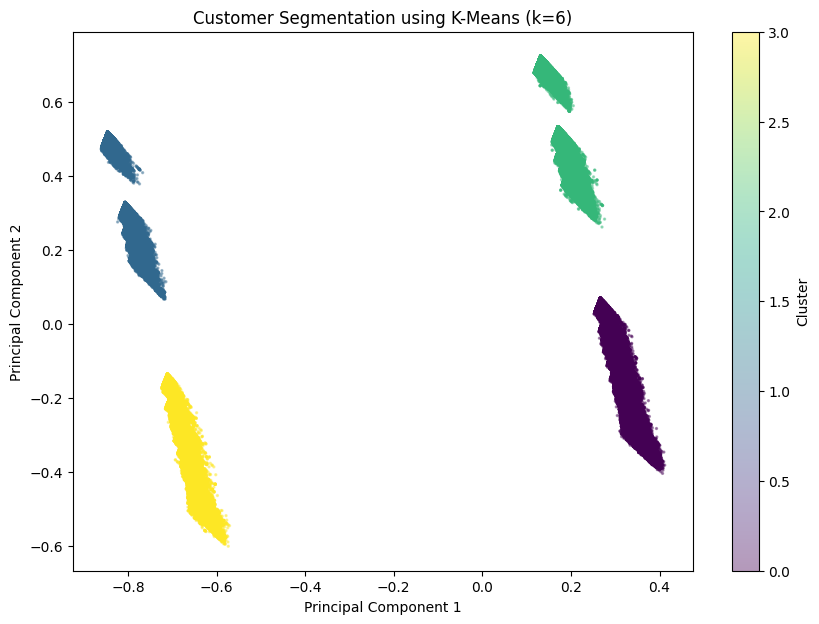

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dx["Cluster"],
    s=2,
    alpha=0.4
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means (k=6)")
plt.colorbar(label="Cluster")

plt.show()

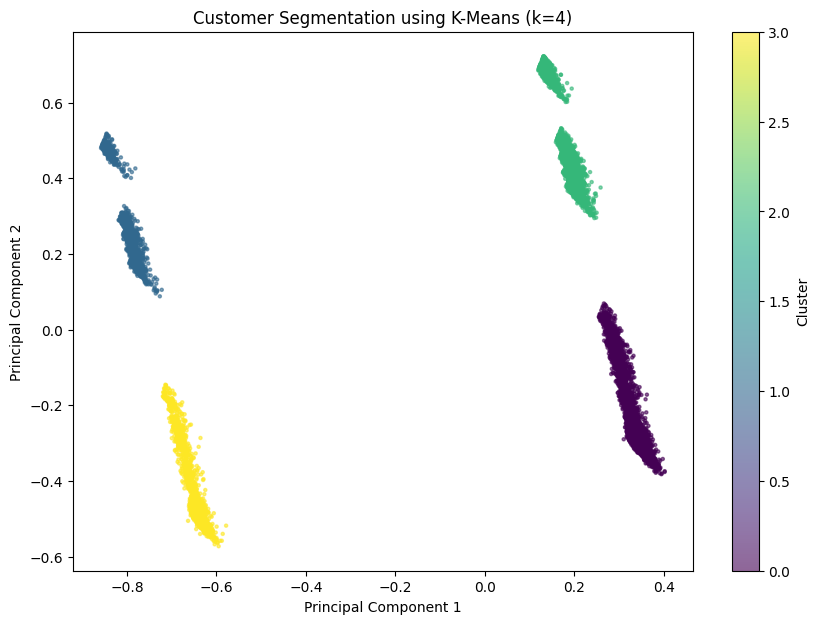

In [ ]:
sample_indices = np.random.choice(X_pca.shape[0], size=10000, replace=False)

X_pca_sample = X_pca[sample_indices]
cluster_sample = dx["Cluster"].iloc[sample_indices]

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_sample[:, 0],
    X_pca_sample[:, 1],
    c=cluster_sample,
    cmap='viridis',
    s=5,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means (k=4)")
plt.colorbar(label="Cluster")

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

sample_indices = np.random.choice(dx_scaled.shape[0], size=50000, replace=False)
dx_sample = dx_scaled.iloc[sample_indices]
cluster_labels_sample = dx['Cluster'].iloc[sample_indices]

sil_score = silhouette_score(dx_sample, cluster_labels_sample)
db_score = davies_bouldin_score(dx_sample, cluster_labels_sample)
ch_score = calinski_harabasz_score(dx_sample, cluster_labels_sample)

print(f"Silhouette Score: {sil_score:.3f}")
print(f"Davies-Bouldin Index: {db_score:.3f}")
print(f"Calinski-Harabasz Index: {ch_score:.3f}")

Silhouette Score: 0.484
Davies-Bouldin Index: 0.844
Calinski-Harabasz Index: 47803.954


In [ ]:
np.random.seed(42)
sample_indices = np.random.choice(dx_scaled.shape[0], size=50000, replace=False)
X_sample = dx_scaled.iloc[sample_indices]

results = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(dx_scaled)
    sample_labels = labels[sample_indices]

    silhouette = silhouette_score(X_sample, sample_labels)
    db = davies_bouldin_score(X_sample, sample_labels)
    ch = calinski_harabasz_score(X_sample, sample_labels)

    results.append([k, silhouette, db, ch])
    print(f"k={k} completed | Sil: {silhouette:.3f} | DB: {db:.3f} | CH: {ch:.0f}")

k=2 completed | Sil: 0.478 | DB: 0.929 | CH: 42332
k=3 completed | Sil: 0.468 | DB: 0.818 | CH: 49061
k=4 completed | Sil: 0.483 | DB: 0.843 | CH: 48070
k=5 completed | Sil: 0.378 | DB: 1.067 | CH: 43669
k=6 completed | Sil: 0.322 | DB: 1.260 | CH: 39211
k=7 completed | Sil: 0.323 | DB: 1.221 | CH: 36699
k=8 completed | Sil: 0.318 | DB: 1.203 | CH: 34279
k=9 completed | Sil: 0.318 | DB: 1.183 | CH: 32350
k=10 completed | Sil: 0.280 | DB: 1.277 | CH: 31022
